In [12]:
import os
import sys
from pathlib import Path

import torch
import pandas as pd

project_root = Path.cwd().parent
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

import config

from data import prepare_data

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Python:         c:\Users\profb\PROJECTS\cxr-disease-classification\.venv\Scripts\python.exe
PyTorch:        2.12.0+cu132
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [4]:
bundle = prepare_data()

type(bundle)

data.DataBundle

In [6]:
bundle.train_df.head()

,image_id,finding_labels,follow_up,patient_id,patient_age,patient_gender,view_position,orig_width,orig_height,pixel_spacing_x,...,target_infiltration,target_mass,target_nodule,target_pleural_thickening,target_pneumonia,target_pneumothorax,bbox_count,bbox_labels,has_bbox,split
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,NaN,False,train
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,0,0,NaN,False,train
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,NaN,False,train
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,NaN,False,train
4,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,NaN,False,train


In [7]:
bundle.val_df.head()

,image_id,finding_labels,follow_up,patient_id,patient_age,patient_gender,view_position,orig_width,orig_height,pixel_spacing_x,...,target_infiltration,target_mass,target_nodule,target_pleural_thickening,target_pneumonia,target_pneumothorax,bbox_count,bbox_labels,has_bbox,split
0,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,...,0,1,1,0,0,0,0,NaN,False,val
1,00000009_000.png,Emphysema,0,9,73,M,PA,2992,2991,0.143,...,0,0,0,0,0,0,0,NaN,False,val
2,00000017_000.png,Effusion|Infiltration|Nodule,0,17,77,M,PA,2500,2048,0.168,...,1,0,1,0,0,0,0,NaN,False,val
3,00000017_001.png,No Finding,1,17,77,M,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,NaN,False,val
4,00000017_002.png,No Finding,2,17,78,M,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,NaN,False,val


In [8]:
bundle.test_df.head()

,image_id,finding_labels,follow_up,patient_id,patient_age,patient_gender,view_position,orig_width,orig_height,pixel_spacing_x,...,target_infiltration,target_mass,target_nodule,target_pleural_thickening,target_pneumonia,target_pneumothorax,bbox_count,bbox_labels,has_bbox,split
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,0,0,0,0,NaN,False,test
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,NaN,False,test
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,NaN,False,test
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,...,1,0,0,0,0,0,0,NaN,False,test
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,NaN,False,test


In [9]:
bundle.class_names

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [10]:
bundle.target_columns

['target_atelectasis',
 'target_cardiomegaly',
 'target_consolidation',
 'target_edema',
 'target_effusion',
 'target_emphysema',
 'target_fibrosis',
 'target_hernia',
 'target_infiltration',
 'target_mass',
 'target_nodule',
 'target_pleural_thickening',
 'target_pneumonia',
 'target_pneumothorax']

In [11]:
bundle.pos_weights

array([  9.573874,  50.25453 ,  29.611828,  61.873398,   9.154601,
        61.712456,  67.81929 , 616.6387  ,   5.321951,  20.328787,
        17.597925,  37.970837,  99.271484,  32.10766 ], dtype=float32)

# Bundle Structure

In [13]:
pd.DataFrame(
    {
        "rows": [
            len(bundle.train_df),
            len(bundle.val_df),
            len(bundle.test_df),
        ],
        "unique_patients": [
            bundle.train_df["patient_id"].nunique(),
            bundle.val_df["patient_id"].nunique(),
            bundle.test_df["patient_id"].nunique(),
        ],
    },
    index=["train", "val", "test"],
)

,rows,unique_patients
train,73499,23807
val,13025,4201
test,25596,2797


In [ ]:
# Check for duplicate image_ids in the combined dataframe
bundle.all_df[["image_id", "image_path", "patient_id", "finding_labels"]].isna().sum()

image_id          0
image_path        0
patient_id        0
finding_labels    0
dtype: int64

In [ ]:
# Check for duplicate image_ids in the combined dataframe
bundle.all_df["image_id"].duplicated().sum()

np.int64(0)

In [ ]:
# Check for patient overlap between train and val sets
len(set(bundle.train_df["patient_id"]) & set(bundle.val_df["patient_id"]))

0

# Label Imbalance

In [17]:
label_stats = pd.DataFrame(
    {
        "positives": bundle.train_df[bundle.target_columns].sum(),
        "prevalence": bundle.train_df[bundle.target_columns].mean(),
        "pos_weight": bundle.pos_weights,
    },
    index=bundle.target_columns,
).sort_values("positives", ascending=False)

label_stats

,positives,prevalence,pos_weight
target_infiltration,11626,0.158179,5.321951
target_effusion,7238,0.098478,9.154601
target_atelectasis,6951,0.094573,9.573874
target_nodule,3952,0.053769,17.597925
target_mass,3446,0.046885,20.328787
target_consolidation,2401,0.032667,29.611828
target_pneumothorax,2220,0.030204,32.107658
target_pleural_thickening,1886,0.025660,37.970837
target_cardiomegaly,1434,0.019510,50.254532
target_emphysema,1172,0.015946,61.712456


In [18]:
bundle.all_df["num_labels"] = bundle.all_df["label_list"].str.len()
bundle.all_df["num_labels"].value_counts().sort_index()

num_labels
0    60361
1    30963
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64

In [19]:
bundle.all_df["is_no_finding"].mean()

np.float64(0.5383606849803781)

In [20]:
cooccurrence = bundle.train_df[bundle.target_columns].T.dot(
    bundle.train_df[bundle.target_columns]
)
cooccurrence

,target_atelectasis,target_cardiomegaly,target_consolidation,target_edema,target_effusion,target_emphysema,target_fibrosis,target_hernia,target_infiltration,target_mass,target_nodule,target_pleural_thickening,target_pneumonia,target_pneumothorax
target_atelectasis,6951,157,624,115,1717,214,157,26,1754,410,342,250,145,299
target_cardiomegaly,157,1434,56,46,496,26,25,5,234,50,50,55,15,18
target_consolidation,624,56,2401,79,637,50,44,1,597,321,261,114,49,90
target_edema,115,46,79,1169,284,9,6,1,518,61,64,28,126,14
target_effusion,1717,496,637,284,7238,177,122,13,2000,705,492,452,138,390
target_emphysema,214,26,50,9,177,1172,17,3,193,93,50,70,10,242
target_fibrosis,157,25,44,6,122,17,1068,7,236,74,93,101,8,35
target_hernia,26,5,1,1,13,3,7,119,17,16,6,5,0,2
target_infiltration,1754,234,597,518,2000,193,236,17,11626,617,864,353,294,340
target_mass,410,50,321,61,705,93,74,16,617,3446,509,228,30,187


# Check Metadata Bias and Split Shift

In [21]:
bundle.all_df.groupby("split")["patient_age"].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,25596.0,47.007579,16.854982,1.0,34.0,49.0,59.0,414.0
train,73499.0,46.778664,16.845229,1.0,35.0,49.0,59.0,413.0
val,13025.0,47.385873,16.771363,1.0,35.0,50.0,59.0,153.0


In [22]:
bundle.all_df.groupby(["split", "patient_gender"]).size().unstack(fill_value=0)

patient_gender,F,M
split,,
test,10714,14882
train,32362,41137
val,5704,7321


In [23]:
bundle.all_df.groupby(["split", "view_position"]).size().unstack(fill_value=0)

view_position,AP,PA
split,,
test,14500,11096
train,25624,47875
val,4686,8339


In [24]:
bundle.all_df.groupby("patient_id").size().describe()

count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
dtype: float64

# Image Inspection

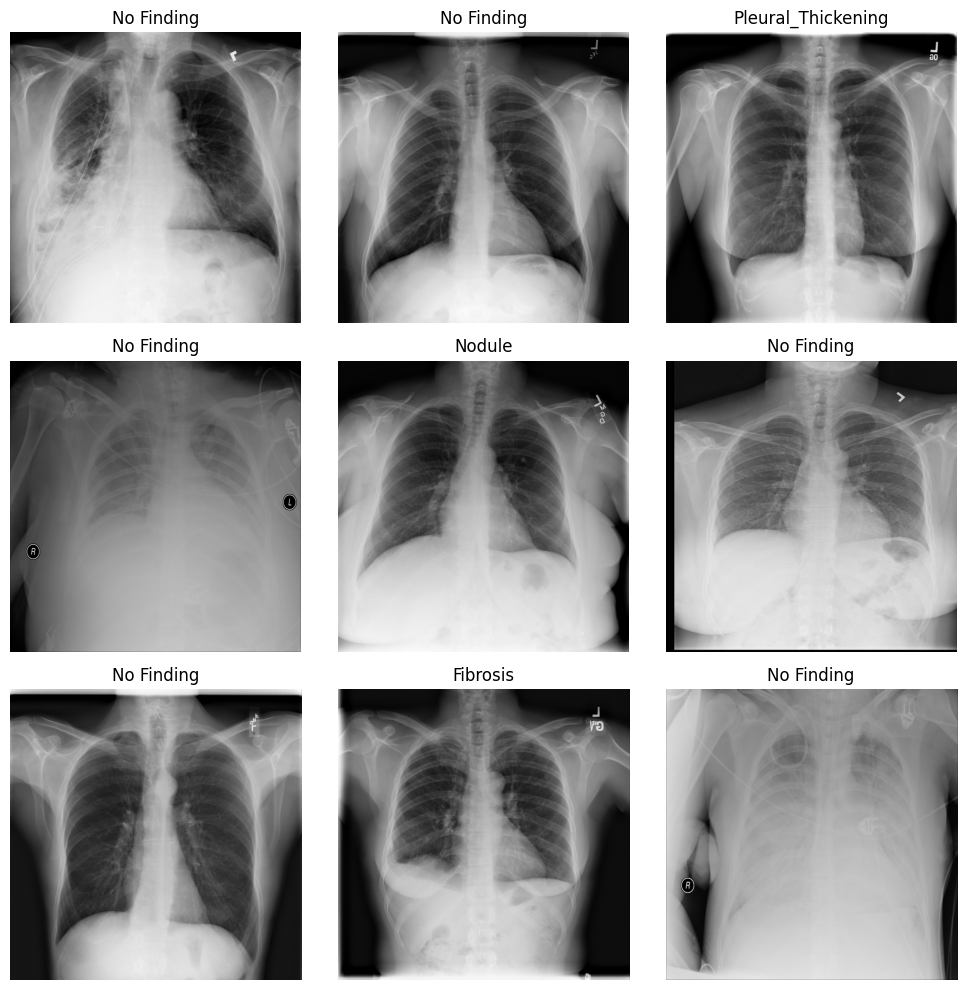

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

sample = bundle.train_df.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(row["finding_labels"])
    ax.axis("off")
plt.tight_layout()

In [27]:
bundle.all_df[["orig_width", "orig_height"]].describe()

,orig_width,orig_height
count,112120.000000,112120.000000
mean,2646.078844,2486.438842
std,341.246429,401.268227
min,1143.000000,966.000000
25%,2500.000000,2048.000000
50%,2518.000000,2544.000000
75%,2992.000000,2991.000000
max,3827.000000,4715.000000


# Diagnostic BBox Data

In [28]:
bundle.all_df["has_bbox"].mean()

np.float64(0.00784873349982162)

In [29]:
bundle.bbox_df["bbox_label"].value_counts()

bbox_label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64

In [30]:
bundle.all_df.groupby("has_bbox")[bundle.target_columns].mean().T

has_bbox,False,True
target_atelectasis,0.101196,0.343182
target_cardiomegaly,0.023292,0.210227
target_consolidation,0.041298,0.082955
target_edema,0.020325,0.047727
target_effusion,0.116909,0.354545
target_emphysema,0.022312,0.038636
target_fibrosis,0.014995,0.020455
target_hernia,0.002023,0.002273
target_infiltration,0.176034,0.354545
target_mass,0.050737,0.156818
